In [6]:
import numpy as np
import pandas as pd
import optuna
import warnings
import itertools
import matplotlib.pyplot as plt
import seaborn as sns

# Dataset e Preprocessing
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.cluster import KMeans
from sklearn.feature_selection import SelectFromModel

# Modelli
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
from sklearn.linear_model import RidgeCV, LassoCV
from sklearn.ensemble import StackingRegressor

# Visualizzazione Optuna
from optuna.visualization import plot_optimization_history

In [7]:
#importazione dei dataset
data = fetch_california_housing()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name="MedHouseVal")
df = pd.concat([X, y], axis=1)

In [8]:
# Rimuoviamo il cap artificiale del target (valori >= 5.0)
df = df[df['MedHouseVal'] < 5.0]

def remove_outliers_iqr(df, columns):
    df_clean = df.copy()
    indices_to_drop = []
    for col in columns:
        Q1 = df_clean[col].quantile(0.25)
        Q3 = df_clean[col].quantile(0.75)
        IQR = Q3 - Q1
        outliers = df_clean[(df_clean[col] < Q1 - 1.5*IQR) | (df_clean[col] > Q3 + 1.5*IQR)].index
        indices_to_drop.extend(outliers)
    return df_clean.drop(list(set(indices_to_drop)))

# Puliamo solo le colonne fisiche soggette a errori
cols_clean = ['AveRooms', 'AveBedrms', 'AveOccup', 'MedInc']
df = remove_outliers_iqr(df, cols_clean)
print(f"Dataset pulito: {df.shape}")

print("2. Generazione Feature Manuale (Log, Quadrati, Prodotti, Rapporti)...")

def generate_manual_combinations(df_input, cols_to_combine):
    df_eng = df_input.copy()
    
    # Escludiamo Lat/Lon/Cluster dai calcoli matematici puri
    math_cols = [c for c in cols_to_combine if c not in ['Latitude', 'Longitude', 'Geo_Cluster']]
    
    print(f"   -> Elaborazione su {len(math_cols)} colonne base...")

    # A. LOGARITMI (Normalizzazione skewness)
    for col in math_cols:
        if df_eng[col].min() >= 0:
            df_eng[f'LOG_{col}'] = np.log1p(df_eng[col])

    # B. QUADRATI (Non-linearità a U)
    for col in math_cols:
        df_eng[f'SQUARE_{col}'] = df_eng[col] ** 2

    # C. PRODOTTI (Interazioni A * B)
    for col1, col2 in itertools.combinations(math_cols, 2):
        col_name = f'MULT_{col1}_x_{col2}'
        df_eng[col_name] = df_eng[col1] * df_eng[col2]
        
    # D. RAPPORTI (Efficienza A / B)
    for col1, col2 in itertools.permutations(math_cols, 2):
        col_name = f'RATIO_{col1}_div_{col2}'
        df_eng[col_name] = df_eng[col1] / (df_eng[col2] + 1e-5) # Epsilon safety

    return df_eng

# --- Geo Features Base ---
sf_coords = (37.7749, -122.4194)
la_coords = (34.0522, -118.2437)
df['Dist_SF'] = np.sqrt((df['Latitude'] - sf_coords[0])**2 + (df['Longitude'] - sf_coords[1])**2)
df['Dist_LA'] = np.sqrt((df['Latitude'] - la_coords[0])**2 + (df['Longitude'] - la_coords[1])**2)

# KMeans Cluster
kmeans = KMeans(n_clusters=10, random_state=42, n_init=10)
geo_scaled = StandardScaler().fit_transform(df[['Latitude', 'Longitude']])
df['Geo_Cluster'] = kmeans.fit_predict(geo_scaled)

X = df.drop('MedHouseVal', axis=1)
y = df['MedHouseVal']

# --- Esecuzione Generazione ---
cols_for_math = [c for c in X.columns if c != 'Geo_Cluster']
X_full = generate_manual_combinations(X, cols_for_math)

# Pulizia post-generazione
X_full.replace([np.inf, -np.inf], np.nan, inplace=True)
X_full.fillna(0, inplace=True)
print(f"   -> Totale Feature create: {X_full.shape[1]}")

# --- Geo Features Base ---
sf_coords = (37.7749, -122.4194)
la_coords = (34.0522, -118.2437)
df['Dist_SF'] = np.sqrt((df['Latitude'] - sf_coords[0])**2 + (df['Longitude'] - sf_coords[1])**2)
df['Dist_LA'] = np.sqrt((df['Latitude'] - la_coords[0])**2 + (df['Longitude'] - la_coords[1])**2)

# KMeans Cluster
kmeans = KMeans(n_clusters=10, random_state=42, n_init=10)
geo_scaled = StandardScaler().fit_transform(df[['Latitude', 'Longitude']])
df['Geo_Cluster'] = kmeans.fit_predict(geo_scaled)

Dataset pulito: (17289, 9)
2. Generazione Feature Manuale (Log, Quadrati, Prodotti, Rapporti)...
   -> Elaborazione su 8 colonne base...
   -> Totale Feature create: 111


/var/folders/l5/gygvzpy97t9d3g10blp2dtd00000gn/T/ipykernel_18270/911176821.py:47: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_eng[col_name] = df_eng[col1] / (df_eng[col2] + 1e-5) # Epsilon safety
/var/folders/l5/gygvzpy97t9d3g10blp2dtd00000gn/T/ipykernel_18270/911176821.py:47: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_eng[col_name] = df_eng[col1] / (df_eng[col2] + 1e-5) # Epsilon safety


   -> Elaborazione su 8 colonne base...
   -> Totale Feature create: 111
3. Selezione Feature Intelligente (Lasso)...


/var/folders/l5/gygvzpy97t9d3g10blp2dtd00000gn/T/ipykernel_18270/911176821.py:47: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_eng[col_name] = df_eng[col1] / (df_eng[col2] + 1e-5) # Epsilon safety
/var/folders/l5/gygvzpy97t9d3g10blp2dtd00000gn/T/ipykernel_18270/911176821.py:47: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_eng[col_name] = df_eng[col1] / (df_eng[col2] + 1e-5) # Epsilon safety
[I 2025-12-09 17:51:12,499] A new study created in memory with name: no-name-c3457ef5-a820-4166-87da-b1e3c0f19044


   -> Feature Mantenute: 43 (su 111)

4. Tuning Iperparametri Robusto (5-Fold CV interna)...
 -> Optimizing XGBoost...


[I 2025-12-09 17:51:23,200] Trial 0 finished with value: 0.4564955913700321 and parameters: {'n_estimators': 1116, 'learning_rate': 0.35399893180157355, 'max_depth': 11, 'subsample': 0.6433899780276195, 'colsample_bytree': 0.8574781361383672, 'alpha': 1.0400806341420837e-08, 'lambda': 5.798076510354794}. Best is trial 0 with value: 0.4564955913700321.
[I 2025-12-09 17:51:25,064] Trial 1 finished with value: 0.4540635012283117 and parameters: {'n_estimators': 765, 'learning_rate': 0.5193846166294082, 'max_depth': 3, 'subsample': 0.941147952120517, 'colsample_bytree': 0.6496274569343247, 'alpha': 0.36623128994025544, 'lambda': 3.6310424072683846e-09}. Best is trial 1 with value: 0.4540635012283117.
[I 2025-12-09 17:51:32,620] Trial 2 finished with value: 0.5037563318629055 and parameters: {'n_estimators': 1017, 'learning_rate': 0.45442905666074807, 'max_depth': 16, 'subsample': 0.7847900288737482, 'colsample_bytree': 0.7229385064150854, 'alpha': 0.03182350340427046, 'lambda': 0.028715123

 -> Optimizing LightGBM...


...

[I 2025-12-09 18:00:40,261] Trial 0 finished with value: 0.42965232921531454 and parameters: {'iterations': 888, 'learning_rate': 0.599725546892782, 'depth': 4, 'l2_leaf_reg': 6.09047692734683, 'subsample': 0.762065506770479}. Best is trial 0 with value: 0.42965232921531454.
[I 2025-12-09 18:00:43,234] Trial 1 finished with value: 0.40358550535263743 and parameters: {'iterations': 1034, 'learning_rate': 0.07536740656602905, 'depth': 4, 'l2_leaf_reg': 8.798972645494503, 'subsample': 0.8025089683800875}. Best is trial 1 with value: 0.40358550535263743.
[I 2025-12-09 18:00:44,835] Trial 2 finished with value: 0.42239299555466614 and parameters: {'iterations': 874, 'learning_rate': 0.45656619687256395, 'depth': 2, 'l2_leaf_reg': 4.030110486505826, 'subsample': 0.7151468726312539}. Best is trial 1 with value: 0.40358550535263743.
[I 2025-12-09 18:01:23,885] Trial 3 finished with value: 0.43781790367716855 and parameters: {'iterations': 1178, 'learning_rate': 0.5016662420252622, 'depth': 10,


BEST CV RMSE -> XGB: 0.4117 | LGBM: 0.4017 | CAT: 0.4029

5. Stacking Ensemble Finale...


Exception ignored in: <function ResourceTracker.__del__ at 0x1073a1800>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 84, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 93, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 118, in _stop_locked
ChildProcessError: [Errno 10] No child processes



 FINAL TEST SET RESULTS (STACKING)
 RMSE: 0.38257
 R^2 : 0.83354

--- Analisi Pesi Meta-Learner (RidgeCV) ---
  Model    Weight
1  lgbm  0.473455
2   cat  0.469677
0   xgb  0.067236

Intercept (Bias): -0.0197


/var/folders/l5/gygvzpy97t9d3g10blp2dtd00000gn/T/ipykernel_18270/2869887822.py:162: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='Weight', data=weights_df, palette='viridis')


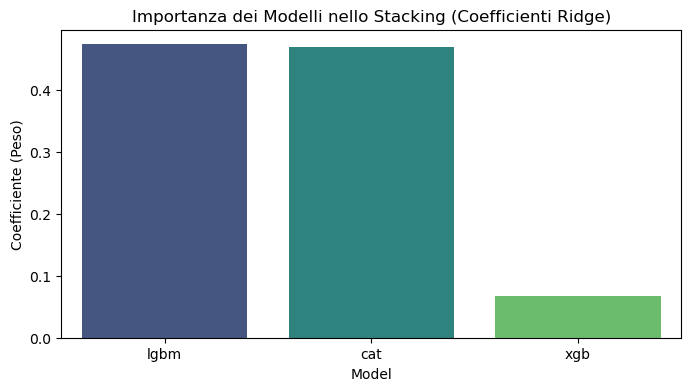


--- Top Features (dal miglior modello base: XGB) ---
RATIO_AveOccup_div_MedInc    0.728392
MULT_Dist_SF_x_Dist_LA       0.058165
RATIO_MedInc_div_AveOccup    0.043059
RATIO_Dist_SF_div_MedInc     0.017821
Longitude                    0.013611
Latitude                     0.012915
MULT_MedInc_x_HouseAge       0.010397
RATIO_Dist_LA_div_Dist_SF    0.009048
MULT_MedInc_x_AveBedrms      0.006797
LOG_Dist_LA                  0.006030
dtype: float32


Exception ignored in: <function ResourceTracker.__del__ at 0x107eed800>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 84, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 93, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 118, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x1226b1800>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 84, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 93, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 118, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x105869800>
Traceback (most recent call last

In [ ]:
X = df.drop('MedHouseVal', axis=1)
y = df['MedHouseVal']

# --- Esecuzione Generazione ---
cols_for_math = [c for c in X.columns if c != 'Geo_Cluster']
X_full = generate_manual_combinations(X, cols_for_math)

# Pulizia post-generazione
X_full.replace([np.inf, -np.inf], np.nan, inplace=True)
X_full.fillna(0, inplace=True)
print(f"   -> Totale Feature create: {X_full.shape[1]}")

# ---------------------------------------------------------
# 3. SELEZIONE FEATURE (LASSO)
# ---------------------------------------------------------
print("3. Selezione Feature Intelligente (Lasso)...")
scaler = RobustScaler()
X_scaled = scaler.fit_transform(X_full)

# LassoCV seleziona automaticamente l'alpha migliore
lasso_selector = SelectFromModel(LassoCV(cv=3, random_state=42, n_jobs=-1, max_iter=2000))
lasso_selector.fit(X_scaled, y)

X_selected = X_full.loc[:, lasso_selector.get_support()]
print(f"   -> Feature Mantenute: {X_selected.shape[1]} (su {X_full.shape[1]})")

# Split Train/Test
X_train, X_test, y_train, y_test = train_test_split(X_selected, y, test_size=0.2, random_state=42)

# ---------------------------------------------------------
# 4. OPTUNA ROBUSTO (3 MODELLI)
# ---------------------------------------------------------
print("\n4. Tuning Iperparametri Robusto (5-Fold CV interna)...")
kf = KFold(n_splits=3, shuffle=True, random_state=42)
N_TRIALS = 20 # Aumenta a 50+ per produzione

# --- A. XGBoost ---
def objective_xgb(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 600, 1200),
        'learning_rate': trial.suggest_float('learning_rate', 0.001, 0.6),
        'max_depth': trial.suggest_int('max_depth', 2, 20),
        'subsample': trial.suggest_float('subsample', 0.6, 0.95),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 0.95),
        'alpha': trial.suggest_float('alpha', 1e-9, 15.0, log=True),
        'lambda': trial.suggest_float('lambda', 1e-9, 15.0, log=True),
        'n_jobs': -1, 'random_state': 42
    }
    model = XGBRegressor(**params)
    scores = cross_val_score(model, X_train, y_train, cv=kf, scoring='neg_root_mean_squared_error', n_jobs=-1)
    return -scores.mean()

print(" -> Optimizing XGBoost...")
study_xgb = optuna.create_study(direction='minimize')
study_xgb.optimize(objective_xgb, n_trials=N_TRIALS)

# --- B. LightGBM ---
def objective_lgbm(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 700, 1300),
        'learning_rate': trial.suggest_float('learning_rate', 0.001, 0.8),
        'num_leaves': trial.suggest_int('num_leaves', 25, 120),
        'feature_fraction': trial.suggest_float('feature_fraction', 0.6, 0.95),
        'bagging_fraction': trial.suggest_float('bagging_fraction', 0.6, 0.95),
        'bagging_freq': trial.suggest_int('bagging_freq', 1, 7),
        'reg_alpha': trial.suggest_float('reg_alpha', 0.01, 10),
        'reg_lambda': trial.suggest_float('reg_lambda', 0.01, 10),
        'n_jobs': -1, 'verbose': -1, 'random_state': 42
    }
    model = LGBMRegressor(**params)
    scores = cross_val_score(model, X_train, y_train, cv=kf, scoring='neg_root_mean_squared_error', n_jobs=-1)
    return -scores.mean()

print(" -> Optimizing LightGBM...")
study_lgbm = optuna.create_study(direction='minimize')
study_lgbm.optimize(objective_lgbm, n_trials=N_TRIALS)

# --- C. CatBoost ---
# Nota: CatBoost in CV pura è lento. Riduciamo leggermente lo spazio o i trial.
def objective_cat(trial):
    params = {
        'iterations': trial.suggest_int('iterations', 700, 1300),
        'learning_rate': trial.suggest_float('learning_rate', 0.001, 0.8),
        'depth': trial.suggest_int('depth', 1, 10),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1, 10),
        'subsample': trial.suggest_float('subsample', 0.6, 0.95),
        'verbose': 0, 'allow_writing_files': False, 'random_state': 42
    }
    model = CatBoostRegressor(**params)
    # CatBoost gestisce il multiprocessing diversamente, n_jobs=-1 in cross_val_score a volte conflict
    scores = cross_val_score(model, X_train, y_train, cv=kf, scoring='neg_root_mean_squared_error', n_jobs=1)
    return -scores.mean()

print(" -> Optimizing CatBoost (potrebbe richiedere tempo)...")
study_cat = optuna.create_study(direction='minimize')
study_cat.optimize(objective_cat, n_trials=10) # Meno trial per CatBoost che è lento

print(f"\nBEST CV RMSE -> XGB: {study_xgb.best_value:.4f} | LGBM: {study_lgbm.best_value:.4f} | CAT: {study_cat.best_value:.4f}")

# ---------------------------------------------------------
# 5. STACKING FINALE
# ---------------------------------------------------------
print("\n5. Stacking Ensemble Finale...")

best_xgb = study_xgb.best_params
best_xgb.update({'n_jobs': -1, 'random_state': 42})

best_lgbm = study_lgbm.best_params
best_lgbm.update({'n_jobs': -1, 'verbose': -1, 'random_state': 42})

best_cat = study_cat.best_params
best_cat.update({'verbose': 0, 'allow_writing_files': False, 'random_state': 42})

estimators = [
    ('xgb', XGBRegressor(**best_xgb)),
    ('lgbm', LGBMRegressor(**best_lgbm)),
    ('cat', CatBoostRegressor(**best_cat))
]

# Il Meta Learner usa le previsioni dei 3 modelli per dare il verdetto finale
stacking = StackingRegressor(
    estimators=estimators,
    final_estimator=RidgeCV(), # RidgeCV è robusto alla collinearità tra modelli
    cv=5,
    n_jobs=-1
)

stacking.fit(X_train, y_train)

# ---------------------------------------------------------
# 6. VALUTAZIONE
# ---------------------------------------------------------
y_pred = stacking.predict(X_test)
final_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
final_r2 = r2_score(y_test, y_pred)

print(f"\n==========================================")
print(f" FINAL TEST SET RESULTS (STACKING)")
print(f"==========================================")
print(f" RMSE: {final_rmse:.5f}")
print(f" R^2 : {final_r2:.5f}")
print(f"==========================================")

# --- 6.1 Analisi dei Coefficienti (Pesi) ---
print("\n--- Analisi Pesi Meta-Learner (RidgeCV) ---")
# Il RidgeCV addestra dei coefficienti per dare un peso a ogni modello base
meta_model = stacking.final_estimator_
model_names = [name for name, _ in stacking.estimators]
coefficients = meta_model.coef_

# Creiamo un DataFrame per visualizzarli bene
weights_df = pd.DataFrame({
    'Model': model_names,
    'Weight': coefficients
}).sort_values(by='Weight', ascending=False)

print(weights_df)
print(f"\nIntercept (Bias): {meta_model.intercept_:.4f}")

# Grafico a Barre dei Pesi
plt.figure(figsize=(8, 4))
sns.barplot(x='Model', y='Weight', data=weights_df, palette='viridis')
plt.title('Importanza dei Modelli nello Stacking (Coefficienti Ridge)')
plt.ylabel('Coefficiente (Peso)')
plt.show()

# --- 6.2 Top Features Assolute ---
print("\n--- Top Features (dal miglior modello base: XGB) ---")
# Recuperiamo XGBoost dall'ensemble addestrato
xgb_fitted = stacking.estimators_[0] 
importances = pd.Series(xgb_fitted.feature_importances_, index=X_train.columns)
print(importances.sort_values(ascending=False).head(10))


**RISULTATI**


========================================== <br>
 FINAL TEST SET RESULTS (STACKING)
========================================== <br>
 RMSE: 0.38020
 R^2 : 0.83560
========================================== <br>

--- Analisi Pesi Meta-Learner (RidgeCV) ---
  Model    Weight
2   cat  0.660385
0   xgb  0.193688
1  lgbm  0.155136

kf = KFold(n_splits=3, shuffle=True, random_state=42)
N_TRIALS = 20 # Aumenta a 50+ per produzione

# --- A. XGBoost ---
def objective_xgb(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 600, 1200),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1),
        'max_depth': trial.suggest_int('max_depth', 3, 9),
        'subsample': trial.suggest_float('subsample', 0.6, 0.95),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 0.95),
        'reg_alpha': trial.suggest_float('reg_alpha', 0.1, 5),
        'reg_lambda': trial.suggest_float('reg_lambda', 0.1, 5),
        'n_jobs': -1, 'random_state': 42
    }
    model = XGBRegressor(**params)
    scores = cross_val_score(model, X_train, y_train, cv=kf, scoring='neg_root_mean_squared_error', n_jobs=-1)
    return -scores.mean()

print(" -> Optimizing XGBoost...")
study_xgb = optuna.create_study(direction='minimize')
study_xgb.optimize(objective_xgb, n_trials=N_TRIALS)

# --- B. LightGBM ---
def objective_lgbm(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 600, 1200),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1),
        'num_leaves': trial.suggest_int('num_leaves', 20, 100),
        'feature_fraction': trial.suggest_float('feature_fraction', 0.6, 0.95),
        'bagging_fraction': trial.suggest_float('bagging_fraction', 0.6, 0.95),
        'bagging_freq': trial.suggest_int('bagging_freq', 1, 7),
        'reg_alpha': trial.suggest_float('reg_alpha', 0.1, 5),
        'reg_lambda': trial.suggest_float('reg_lambda', 0.1, 5),
        'n_jobs': -1, 'verbose': -1, 'random_state': 42
    }
    model = LGBMRegressor(**params)

  scores = cross_val_score(model, X_train, y_train, cv=kf, scoring='neg_root_mean_squared_error', n_jobs=-1)
    return -scores.mean()

print(" -> Optimizing LightGBM...")
study_lgbm = optuna.create_study(direction='minimize')
study_lgbm.optimize(objective_lgbm, n_trials=N_TRIALS)

# --- C. CatBoost ---
# Nota: CatBoost in CV pura è lento. Riduciamo leggermente lo spazio o i trial.
def objective_cat(trial):
    params = {
        'iterations': trial.suggest_int('iterations', 600, 1200),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1),
        'depth': trial.suggest_int('depth', 4, 10),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1, 10),
        'subsample': trial.suggest_float('subsample', 0.6, 0.95),
        'verbose': 0, 'allow_writing_files': False, 'random_state': 42
    }
    model = CatBoostRegressor(**params)
    # CatBoost gestisce il multiprocessing diversamente, n_jobs=-1 in cross_val_score a volte conflict
    scores = cross_val_score(model, X_train, y_train, cv=kf, scoring='neg_root_mean_squared_error', n_jobs=1)
    return -scores.mean()

print(" -> Optimizing CatBoost (potrebbe richiedere tempo)...")
study_cat = optuna.create_study(direction='minimize')
study_cat.optimize(objective_cat, n_trials=10) # Meno trial per CatBoost che è lento
